# Model creation

author: @Embra-Schuilenburg

COMP 432: Main Project

This document will define functions, classes, and scripts for the models that will be used later in this project. Models that will be created include:

- 1D single-task CNNs
- 1D multi-task CNNs
- ? feature extractor setup

For each model this notebook will:
- Define the basic structure of the model if a (sufficient prexisting implementation doesn't exist)
- Define any needed training, validation, or direct solution methods
- Implement performance monitoring, optimization, and hyperparameter tuning methods (although no optimization or tuning will be performed in this notebook)

Models will be constructed as general models with specifiable parameters that can be adjusted by experiment. Referring to the model as 'general' is to say that numerous data embedding strategies may be experimented with; as finding the ideal fMRI encoding is a very important factor in the success of any model used on it. As such, models should be able to process any data of a similar modality even if it's dimensions aren't identical.

## Imports and packages

In [12]:
from helper_functions import load_saved_run
import importnb
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

---

# 1D single-task CNNs

**Overview**
In this section the report will outline and then construct the framework for a general single signal predicting 1D CNNs that will be used later in this project. 

**I/O details**
Expected inputs: one run of ROIs averaged over a window for each sequnce (*see figure below*)
Input shape: num_rois, seq_len (100, 60)
Target shape: 1, seq_len (1, 60) vector of scalers

**Hyperparameters**:
- Input channels = 1
- Output channnels = 1
- Kernel size = 100x3
- Padding = one zero on each end
- Stride length = 0

Expected inputs:
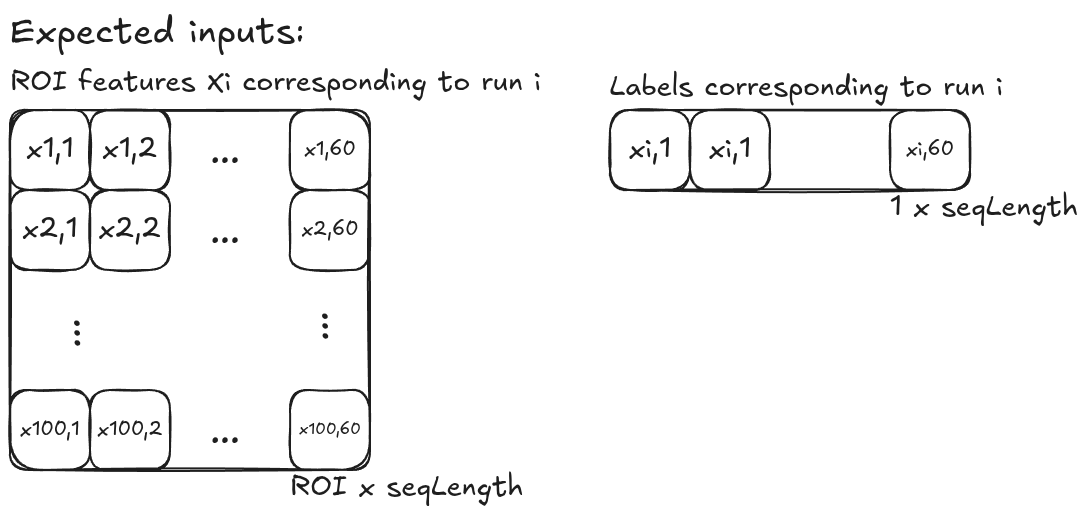

## Data loading, splitting, and normalization functions\

Runs will be collected from the processed-data folder as was specified in `1-data-preprocessing.ipynb`. 

Please note two important fact regarding the data:

1. It is essential that although a run is considered a single input, splitting is performed by participant. This is essential because should inputs be split by row, there would be the possibility of data leakage in which the model is evaluated on data from a participant it was trained on. 
2. Normalization of features and of signal labels is not required as they have been normalized already. ROI features were normalized during preprocessing, and label values were normalized during data collection.


In [13]:
# Data collection method

def collect_run_records(output_dir):
    """
    Find all saved run-level npz files and return records.

    Expected structure:
        output_dir/
            sub-01/
                run-1/
                    features_and_labels.npz
                    trial_metadata.csv
    """
    output_dir = Path(output_dir)
    npz_paths = sorted(output_dir.glob('sub-*/run-*/features_and_labels.npz'))

    if len(npz_paths) == 0:
        raise FileNotFoundError(f'No run files found under: {output_dir}')

    records = []
    for npz_path in npz_paths:
        subject_id = npz_path.parent.parent.name
        run_id = npz_path.parent.name

        records.append({
            'subject_id': subject_id,
            'run_id': run_id,
            'npz_path': npz_path
        })

    return records


# Data splitting method

def split_records_by_subject(records, train_frac=0.70, val_frac=0.15, test_frac=0.15, seed=67):
    """
    Split at the subject level to avoid leakage. 
    Splits should be passed as decimals between 0.0 and 1.0 and should sum to 1.
    All runs from a subject stay in exactly one split.
    """
    subjects = sorted({rec['subject_id'] for rec in records})
    n_subjects = len(subjects)
    rng = np.random.default_rng(seed)
    rng.shuffle(subjects)

    n_test = max(1, int(round(test_frac * n_subjects)))
    n_val = max(1, int(round(val_frac * n_subjects)))
    n_train = n_subjects - n_val - n_test

    train_subjects = set(subjects[:n_train])
    val_subjects = set(subjects[n_train:n_train + n_val])
    test_subjects = set(subjects[n_train + n_val:])

    train_records = [r for r in records if r['subject_id'] in train_subjects]
    val_records = [r for r in records if r['subject_id'] in val_subjects]
    test_records = [r for r in records if r['subject_id'] in test_subjects]

    return train_records, val_records, test_records


# Data set

class RunSequenceDataset(Dataset):
    """
    One item = one run.

    Returns:
        x       : [n_trials, n_rois]
        y       : [n_trials]       (single-task target sequence)
        length  : int
    """

    def __init__(self, records, target_name='surprise'):
        self.records = records
        self.target_name = target_name

        if target_name not in {'surprise', 'V'}:
            raise ValueError('target_name must be "surprise" or "V"')

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        X, _, y_surprise, y_V, roi_names, y_names = load_saved_run(
            rec['npz_path'])

        X = X.astype(np.float32)

        if self.target_name == 'surprise':
            y = y_surprise.astype(np.float32)
        else:
            y = y_V.astype(np.float32)

        # TODO: update graphic to match dataloader instance dimensions (transpose)
        item = {
            'x': torch.from_numpy(X),   # [n_trials, n_rois]
            'y': torch.from_numpy(y),   # [n_trials]
            'length': X.shape[0],
        }

        return item

In [16]:
# Testing scratch-block

records = collect_run_records('processed_data')
records

train, val, test = split_records_by_subject(records=records)

print(len(train),
      len(test),
      len(val))

train_dataset = RunSequenceDataset(
    train,
    target_name='surprise'
)

240 54 54


## Single-task 1D CNN

## Training and eval functions

## Testing

# 1D multi-task CNNs

# Linear models

# Multi-task ElasticNet models